## **ABOUT WALMART**

- Walmart is one of the biggest retail companies in the world.
- It started in the United States in 1962 and now has stores in many countries
- Walmart runs large stores like supermarkets and department stores where people can buy groceries, clothes, electronics, and many other things.
  - Walmart serves over 100 million customers every week.
  - It is known for offering low prices on everyday items.
  - The company has millions of employees around the world.
  - Walmart also sells products online and uses data and technology to understand customer needs and improve shopping experiences.

### **PROBLEM STATEMENT**
- Walmart wants to analyze customer behavior to determine if spending habits differ across gender, marital status, and age groups during Black Friday.
- They specifically want to know:
  - **Do women spend more per transaction than men?**
  - **How does spending differ across other customer segments?**
  - **Can confidence intervals and the Central Limit Theorem help estimate the average population spending?**

### **IMPORTING LIBRARIES**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from  scipy import stats

### **LOADING DATASET**

In [2]:
# Load the dataset
df = pd.read_csv('walmart_data.txt')

###**PREVIEW THE DATSET**

In [3]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


###**DATASET**

In [4]:
df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969
...,...,...,...,...,...,...,...,...,...,...
550063,1006033,P00372445,M,51-55,13,B,1,1,20,368
550064,1006035,P00375436,F,26-35,1,C,3,0,20,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,365


#Observation:
- The dataset contains transactional data from walmart's Black Friday Sales, with a total of 550068 records and 10 features.
- Each row represents a unique product purchase made by a customer.
- The dataset includes customer demographic details such as; Gender, Age, Occupation, Marital status.
- **Motive:** Analyze customer purchase behavior during Black Friday sales at Walmart.

###**INFORMATION OF THE DATASET**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


- The datset with 550,068 entries and 10 columns
- Total rows : 550,068, indicating there are 550,068 customer transactions.
- Total columns : 10, representing various customer and transaction attributes.
- All columns have 550,068 non-null entries, meaning there are no missing values in the dataset.

###**SHAPE, SIZE, AND DIMENSIONS**

In [6]:
# Shape of the dataset
print(f"The shape of the dataset      : {df.shape}")

# Size of the dataset
print(f"The size of the dataset       : {df.size}")

#Dimensions the dataset
print(f"The dimensions of the dataset : {df.ndim}")

The shape of the dataset      : (550068, 10)
The size of the dataset       : 5500680
The dimensions of the dataset : 2


- This dataset contains a lot of demographic and transactional data that can be analyzed for customer segmentation, purchasing patterns, and other insights related to consumer behaviour.

###**TO GET ALL ATTRIBUTES**

In [7]:
# To get all features Names
df.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category',
       'Purchase'],
      dtype='object')

###**DATA TYPES OF ALL ATTRIBUTES**

In [8]:
df.dtypes

,0
User_ID,int64
Product_ID,object
Gender,object
Age,object
Occupation,int64
City_Category,object
Stay_In_Current_City_Years,object
Marital_Status,int64
Product_Category,int64
Purchase,int64


- 5 Columns are of type int64 and remaining 5 columns are of type Object

###**STATISTICAL SUMMARY OF THE DATA**

In [9]:
df.astype('object').describe()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
count,550068,550068,550068,550068,550068,550068,550068,550068,550068,550068
unique,5891,3631,2,7,21,3,5,2,20,18105
top,1001680,P00265242,M,26-35,4,B,1,0,5,7011
freq,1026,1880,414259,219587,72308,231173,193821,324731,150933,191


#Observation:
- The dataset contains more male customers than female customers as males appears 414,259 times.
- The age group 26-35 is the most common, with 219,587 transactions, This age group is biggest shopper base during black friday.
- There are 21 unique occupation codes, and occupation code 4 is the most frequent appearing 72,308 times.
- Unmarried customers make up the larger segment of the customer base compared to married customers.

In [10]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,23961.000000


#Observation:
- The average occupation level is around 8, with values ranging from 0 to 20, showing wide variety of job types among customers.
- Most users are unmarried, as indicated by the average marital status being closer to 0 Labeled as Unmarried.
- Customers bought products from 20 different categories with most purchases falling into lower-numbered categories
- The average purchase amount is approximately 9,264, with most customers spending between 5823 and 12,054.

###**HANDLING MISSING VALUES**

In [11]:
# Check for missing values
df.isnull().any()

,0
User_ID,False
Product_ID,False
Gender,False
Age,False
Occupation,False
City_Category,False
Stay_In_Current_City_Years,False
Marital_Status,False
Product_Category,False
Purchase,False


In [12]:
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category,0
Purchase,0


###**TOTAL MISSING VALUES IN THE DATASET**

In [13]:
df.isnull().sum().sum()

np.int64(0)

###**VALUE COUNTS AND UNIQUE ATTRIBUTES**

In [14]:
df['Gender'].value_counts()

,count
Gender,
M,414259
F,135809


#Observation:
- In the Walmart black friday data, more men are shopping than women.
- There are about 4,14,000 male customers and 1,36,000 female customers.
- This means men shop more during black friday sales.

In [15]:
# Value counts for Age
df['Age'].value_counts()

,count
Age,
26-35,219587
36-45,110013
18-25,99660
46-50,45701
51-55,38501
55+,21504
0-17,15102


#Observation:
- Most customers who shop during walmart's black friday sales are between 26 and 35 years old(about 2,20,000 people)
- The second largest group is 36-45 years old(around 1,10,000.
- Followed by 18 to 25 years old and very few customers are above 55 or below 18

In [16]:
# Value counts for Occupation
df['Occupation'].value_counts().head()

,count
Occupation,
4,72308
0,69638
7,59133
1,47426
17,40043


#Observation:
- The most common occupation among walmart's black friday Shoppers isOccupation 4 with around 72,308 people.
- This is followed by occupation 0 about 69,638 then occupation 7 around 59,133 occuaption 1 around 47,426 and occupation 17 around 40043

In [17]:
# Value counts for City_Category
df['City_Category'].value_counts()

,count
City_Category,
B,231173
C,171175
A,147720


#Observation:
- Most shoppers come from city B with about 2,31,173 People
- Next is City C with around 1,71,175 customers.
- City A is the least with 1,47,720

In [18]:
# Value counts for Stay_In_Current_City_Years
df['Stay_In_Current_City_Years'].value_counts()

,count
Stay_In_Current_City_Years,
1,193821
2,101838
3,95285
4+,84726
0,74398


#Observation:
- The highest number of customers have been livingin their current city for 1 year.
- This is followed by those staying for 2 years and 3 years
- Fewer customers have lived in their city for 4+ years
- The least are those who just moved around 74,396.

In [19]:
# value counts for Marital_status
df['Marital_Status'].value_counts()

,count
Marital_Status,
0,324731
1,225337


#Observation:
- The data shows that 3,24,731 customers are not married(0) and 2,25,337 customers are married(1)

In [20]:
# Value counts for Product_Category
df['Product_Category'].value_counts().head()

,count
Product_Category,
5,150933
1,140378
8,113925
11,24287
2,23864


#Observation:
- Most customers are buying products from category 5, followed by category 1 and 8
- These three categories are the most popular.

- **UNIQUE ATTRIBUTES**

In [21]:
# Unique attributes for user_ID
df['User_ID'].nunique()

5891

- The dataset has a total of 5891 unique users

In [22]:
# Descriptive statistics for Purchase
purchase_stats = df['Purchase'].describe()
purchase_stats

,Purchase
count,550068.000000
mean,9263.968713
std,5023.065394
min,12.000000
25%,5823.000000
50%,8047.000000
75%,12054.000000
max,23961.000000


#Observation:
- Most people spent around ₹9,300, but the spending amount varies a lot.
- Half of the customers spent less than ₹8,059.
- The top 25% of customers spent more than ₹12,065.
- A few customers made very small purchases (as low as ₹185), while some spent up to ₹23,961.
- The data has a wide range, indicating that there are both low and high spenders.

### **DISTRIBUTION OF PURCHASE AMOUNTS**

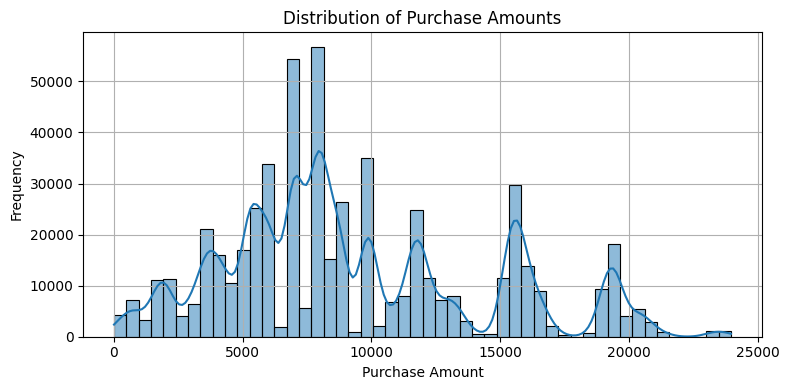

In [23]:
plt.figure(figsize=(8,4))
sns.histplot(df['Purchase'], bins=50, kde=True)
plt.title("Distribution of Purchase Amounts")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

#Observation:
- Most customers made purchases between 5000 and 12000.
- There are several peaks in the graph, showing that many people made purchases around specific values like 8000, 10,000, 15,000 and 20,000
- Purchase are spread out from very low amounts to over 20,000 but high purchases are less frequent
- The distribution has a long tail on the right,Right-skewed data. meaning a few people spent much more than most others.

- **CONVERTING VARIABLES INTO CATEGORIES**

In [24]:
# Convert categorical columns to 'category' type
categorical_cols = ['Gender', 'Age', 'Occupation', 'City_Category', 'Marital_Status']
for col in categorical_cols:
    df[col] = df[col].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   User_ID                     550068 non-null  int64   
 1   Product_ID                  550068 non-null  object  
 2   Gender                      550068 non-null  category
 3   Age                         550068 non-null  category
 4   Occupation                  550068 non-null  category
 5   City_Category               550068 non-null  category
 6   Stay_In_Current_City_Years  550068 non-null  object  
 7   Marital_Status              550068 non-null  category
 8   Product_Category            550068 non-null  int64   
 9   Purchase                    550068 non-null  int64   
dtypes: category(5), int64(3), object(2)
memory usage: 23.6+ MB


- Memory usage decreases after converting categorical variables to the category data type

## **UNIVARIATE ANALYSIS**

- To analyze the distribution o individual variables, identify patterns, and detect outliers in the dataset

###**PURCHASE AMOUNT DISTRIBUTION**

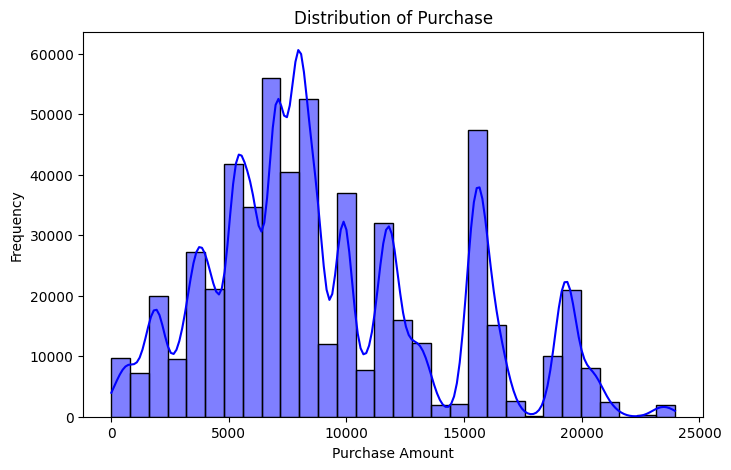

In [25]:
# Distribution plot for purchase
plt.figure(figsize = (8,5))
sns.histplot(df['Purchase'], kde = True, color = 'blue', bins = 30)
plt.title('Distribution of Purchase')
plt.xlabel('Purchase Amount')
plt.ylabel('Frequency')
plt.show()

#Observation:
- Displays the frequency distribution of the purchase amounts.
- The data appears to have a multimodal distribution with several peaks.
- The mojority of purchases amounts are concentrated between 5000 and 15000.
- The most frequent purchase amounts lie between 5000 and 10000 peaking around 7000-8000
purchase amounts above 20000 are less frequent

###**AGE DISTRIBUTION**

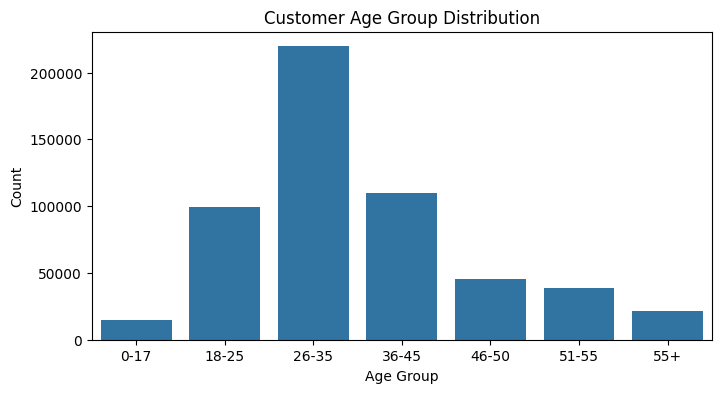

In [26]:
plt.figure(figsize=(8, 4))
sns.countplot(x='Age', data=df, order=sorted(df['Age'].unique()))
plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

#Observation:
- The age group 26-35 has the highest number of customers.
- This means people in this age group shop the most
- The 36-45 group also has a lot of customers, just a little less thanthe top group.
- Very few customers are in the 0-17 or 55+ age groups
- The 46-55 groups have fewer customers than younger adult but more than the youngest and oldest.

### **GENDER DISTRIBUTION**

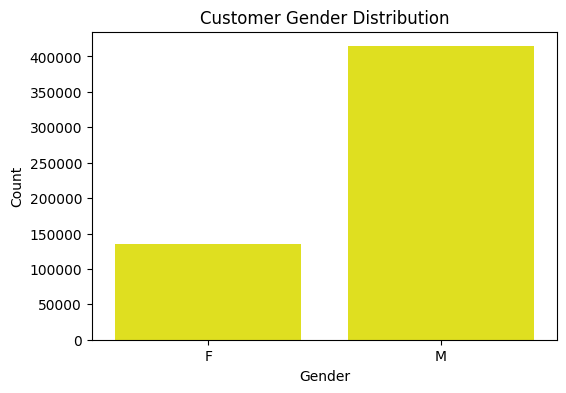

In [27]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=df,color = 'yellow')
plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

###**MARITAL STATUS DISTRIBUTION**

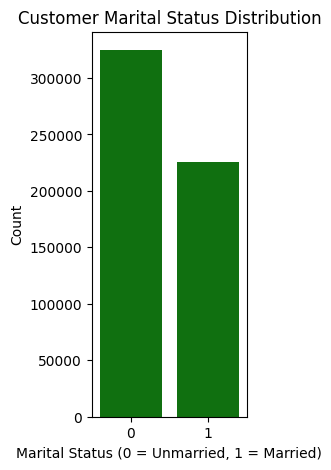

In [28]:
plt.figure(figsize=(2,5))
sns.countplot(x='Marital_Status', data=df,color = 'Green')
plt.title("Customer Marital Status Distribution")
plt.xlabel("Marital Status (0 = Unmarried, 1 = Married)")
plt.ylabel("Count")
plt.show()

###**BOXPLOT FOR PURCHASE**

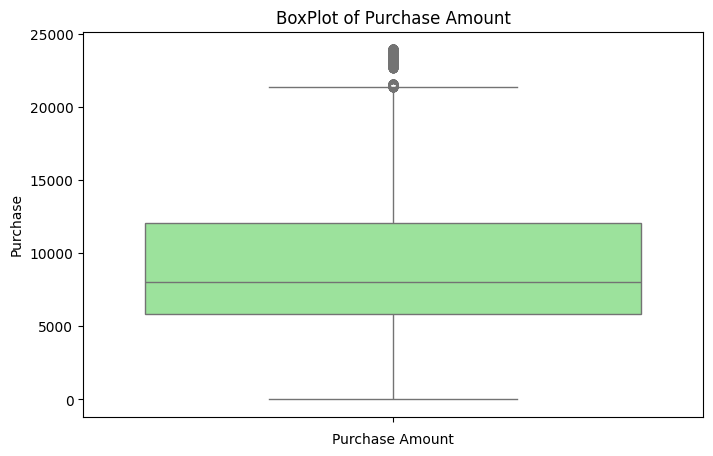

In [29]:
# Boxplot for purchase
plt.figure(figsize = (8,5))
sns.boxplot(df['Purchase'], color = 'lightgreen')
plt.title('BoxPlot of Purchase Amount')
plt.xlabel('Purchase Amount')
plt.show()

#Observation:
- Most people spend between 5000 & 13000.
- The average/median purchase is around 8000.
- The dots above the box are outliers, meaning a few people spent much more than usual (above ₹21,000).

###**ANALYZING THE CITY CATEGORY**

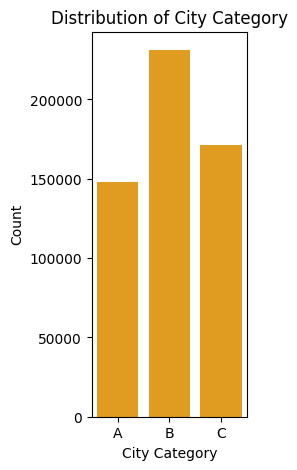

In [30]:
# Count plot for city category
plt.figure(figsize = (2,5))
sns.countplot(x = df['City_Category'],color = 'orange')
plt.title('Distribution of City Category')
plt.xlabel('City Category')
plt.ylabel('Count')
plt.show()

#Observation
- Among the 3 categories(A,B,C), city category B has the highest number of entries, indicating that it represents the largest group in the dataset.
- City category C has a slightly lower count than city B but is larger compared to City A

## **BIVARIATE ANALYSIS**

- To explore relationships between two variables, understand patterns, and identify potential correlations or dependencies.

###**GENDER VS. PURCHASE**

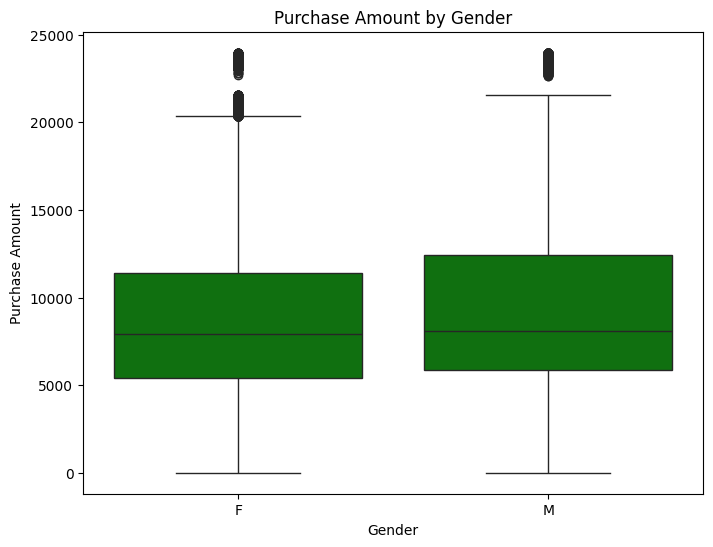

In [31]:
# Boxplot for Gender vs. Purchase
plt.figure(figsize = (8,6))
sns.boxplot(x = df['Gender'], y = df['Purchase'],color = 'Green')
plt.title('Purchase Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Purchase Amount')
plt.show()

#Observation:
- Spending range is similar for both genders.
- The median line is around 7800 for both male and female customers.
- There are some very high purchases in both male and female groups, showing that few customers from both genders spend a lot more than average.
- Based on the box plot, there is no big difference in spending behaviour between males nad females.

###**AGE VS. PURCHASE**

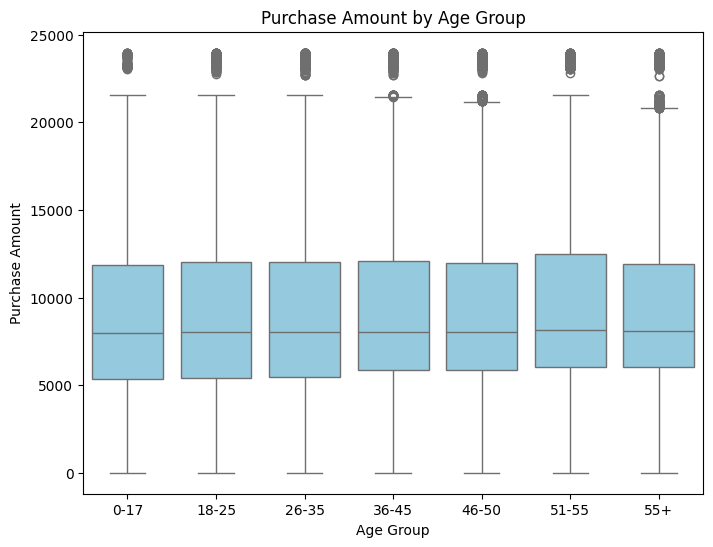

In [32]:
# Boxplot for Age Vs. Purchase
plt.figure(figsize = (8,6))
sns.boxplot(x = df['Age'], y = df['Purchase'],color = 'skyblue')
plt.title('Purchase Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Purchase Amount')
plt.show()

#Observation:
- The spending is almost the same no matter what age group the customer belong to.
- The median line is nearly the same across age groups around 7,800 - 8,000
- High spenders are present in all age groups, outliers in all age groups.
- The 51-55 age group box is slightly taller.

###**CITY CATEGORY VS. PURCHASE**

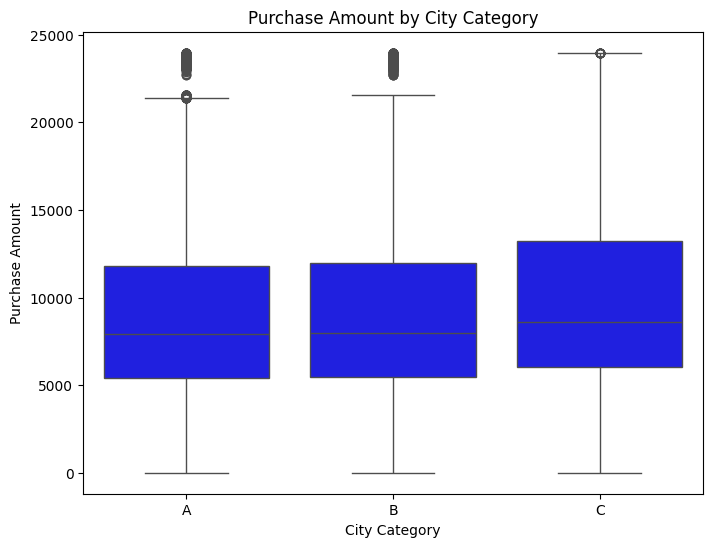

In [33]:
# Boxplot for city_category vs. Purchase
plt.figure(figsize = (8,6))
sns.boxplot(x = df['City_Category'], y = df['Purchase'],color = 'blue')
plt.title('Purchase Amount by City Category')
plt.xlabel('City Category')
plt.ylabel('Purchase Amount')
plt.show()

#Observation:
- The provided boxplot compares the purchase amounts across three city categories (A,B, and C).
- The median purchase amount appears similar across all three city categories.
- B shows a slightly wider IQR, Indicating higher variability in spending.
- A has a narrower IQR compared to B and C, indicating more consistent spending behaviour
- City B has a higher range in spending.

###**MARITAL STATUS VS. PURCHASE**

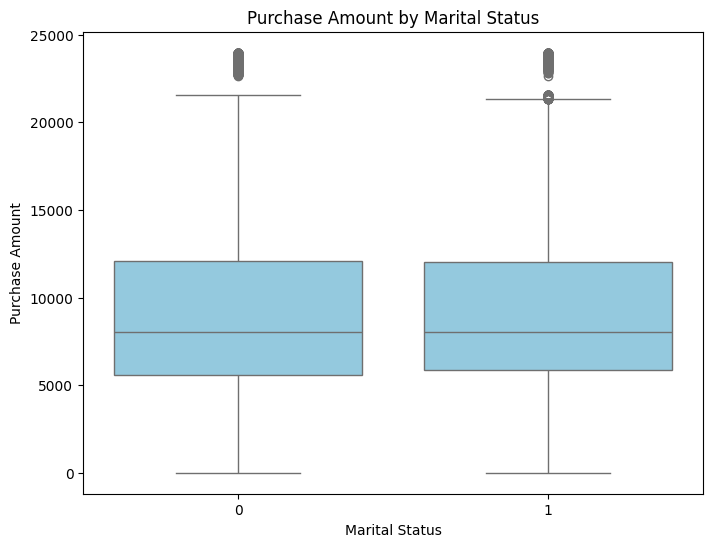

In [34]:
# Boxplot for Marital_status vs. Purchase
plt.figure(figsize = (8,6))
sns.boxplot(x = df['Marital_Status'], y = df['Purchase'],color = 'skyblue')
plt.title('Purchase Amount by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Purchase Amount')
plt.show()

#Observation:
- There no big difference in typical spending between married and unmarried people
- Both groups show a wide range of spending and contain outliers.
- The box for married customers is a bit taller, married people show a bit more variation in their spending compared to unmarried ones.

###**OCCUPATION VS. PURCHASE**

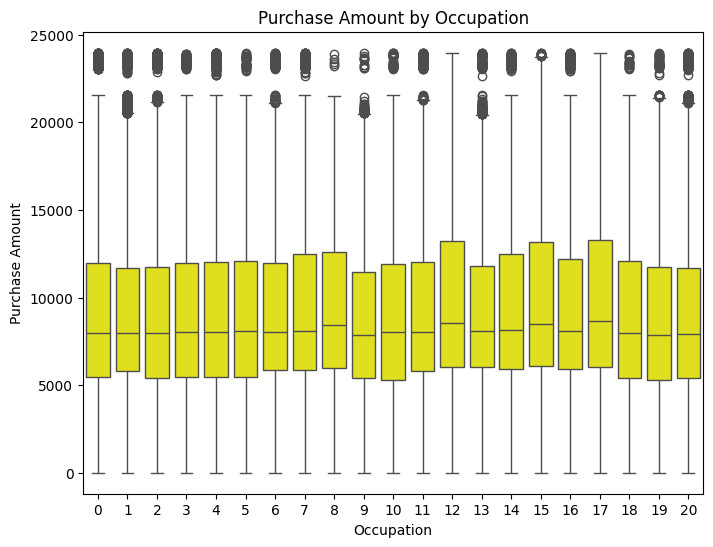

In [35]:
# Boxplot for Occupation vs. Purchase
plt.figure(figsize = (8,6))
sns.boxplot(x = df['Occupation'], y = df['Purchase'],color = 'yellow')
plt.title('Purchase Amount by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Purchase Amount')
plt.show()

#Observation:
- The median purchase amounts are not the same for all occupation codes.
- Occupation codes 12, 15, and 17 show higher median purchase amounts and wider IQR's indicating more spending.
- Occupation code like 0, 1, and 10 have lower medians less spending.
- Every occupation has outliers indicating some individuals in each group spend significantly more than the rest.

###**STAY IN CURRENT CITY YEARS VS. PURCHASE**

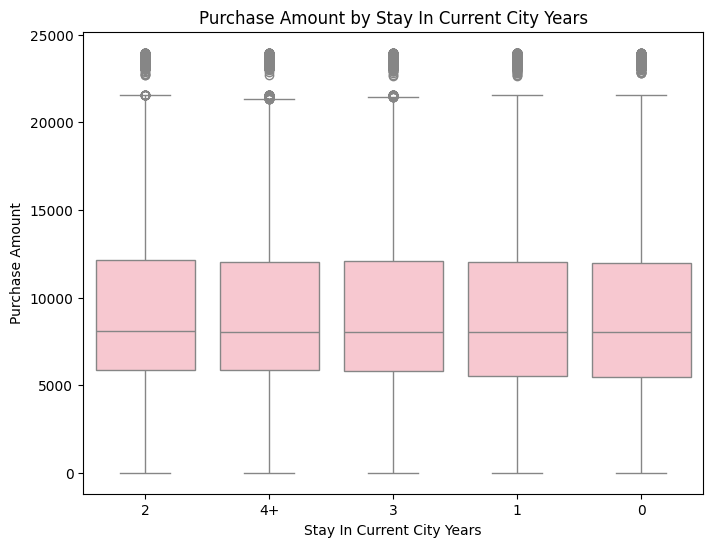

In [36]:
# Boxplot for Stay_In_Current_City_Years vs. Purchase
plt.figure(figsize = (8,6))
sns.boxplot(x = df['Stay_In_Current_City_Years'], y = df['Purchase'],color = 'pink')
plt.title('Purchase Amount by Stay In Current City Years')
plt.xlabel('Stay In Current City Years')
plt.ylabel('Purchase Amount')
plt.show()

#Observation:
- The median and ranges for all categories(0,1,2,3,4+ years) are very similar, showing the length of stay doesn't strongly affect purchase behaviour.
- Those who stayed for 2 years appear to have a slightly higher median purchase amount.
- Outliers are present in all groups.
- The box sizes are nearly equal across all categories, which suggests similar purchase behaviour across these groups.

## **MULTIVARIATE ANALYSIS**

###**GENDER & AGE VS. PURCHASE**

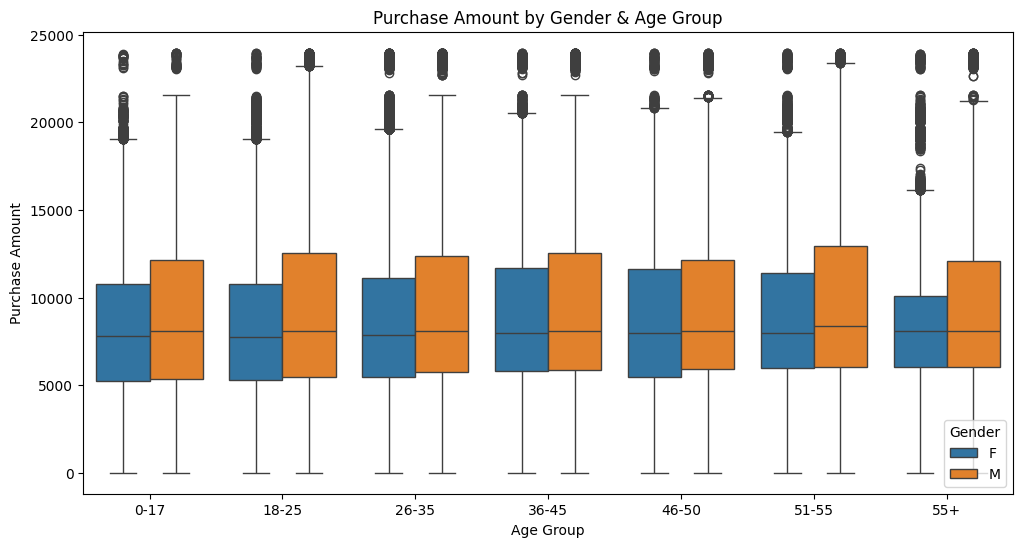

In [37]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Age', y='Purchase', hue='Gender', data=df, order=sorted(df['Age'].unique()))
plt.title("Purchase Amount by Gender & Age Group")
plt.xlabel("Age Group")
plt.ylabel("Purchase Amount")
plt.show()

#Observation:
- The median purchase amount for males is consisntently higher than that for females.
- Highest spending age group is 51-55(Males)
- Females have relatively consistent spending across age groups.
- Both genders between 26 to 55 show higher and more spread - out spending than younger or older groups.
- Younger(0-17) and older(55+) groups spend less.
- Outliers across all groups.

###**GENDER & CITY CATEGORY VS. PURCHASE**

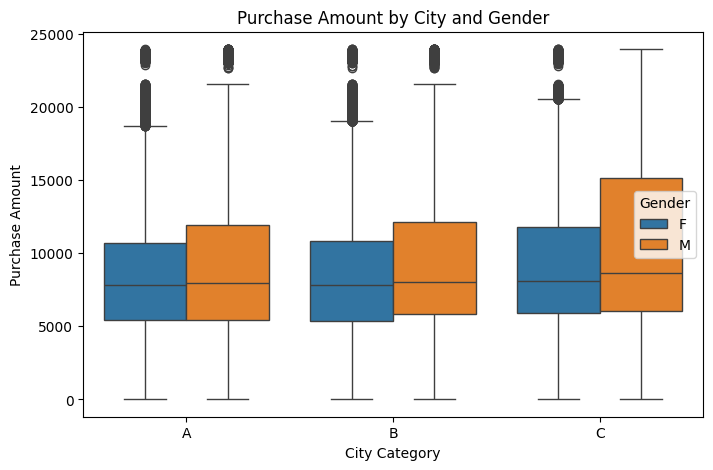

In [38]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='City_Category', y='Purchase', hue='Gender', data=df)
plt.title("Purchase Amount by City and Gender")
plt.xlabel("City Category")
plt.ylabel("Purchase Amount")
plt.show()

#Observation:
- Males spend more than females in all cities.
- City C males spend the most out of all groups.
- Female spending is similar across all cities.
- Biggest difference between male and female spending is in City C.
- There are some high spenders(outliers) in every group.

###**AGE & MARITAL STATUS VS. PURCHASE**

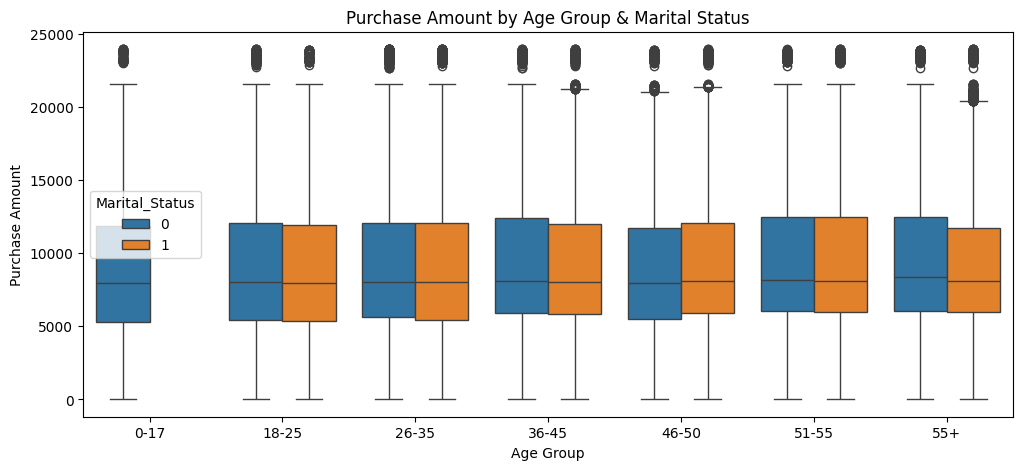

In [39]:
plt.figure(figsize=(12, 5))
sns.boxplot(x='Age', y='Purchase', hue='Marital_Status', data=df, order=sorted(df['Age'].unique()))
plt.title("Purchase Amount by Age Group & Marital Status")
plt.xlabel("Age Group")
plt.ylabel("Purchase Amount")
plt.show()

#Observation:
- Spending is fairly similar between married(1) and unmarried(0) people across all age groups.
- Unmarried people(0) slightly spend more than married in younger age groups(like 0-17 and 18-25)
- In middle and older age groups, the difference in spending between marital status becomes minimal.
- All age groups have high - value purchases (outliers).
- Average purchase amount is stable across age groups, regardless of marital status.

###**STATISTICAL ANALYSIS**

**Walmart has millions of customers. It's impossible to study each one individually**
- **Take a sample(a small portion of the data)**
- **Analyze it using statistical methods and draw conclusions about the whole population**
- **Walmart can compare male and female spending.**
- **Understand which age groups are spending more**
- **Analyze customer behaviour to plan marketing, offers, and inventory.**

###**Why Statistical Analysis Is Important**
- Visualizations like Box plots or bar charts are great for exploring data visually.
- But they often don't tell us whether a pattern is significantly.

###**CLT**
- **When you take many random samples from any population, the distribution of their sample means will approximate a normal distribution, regardless of the population's actual distribution**

###**CLT FOR MALE PURCAHSES**

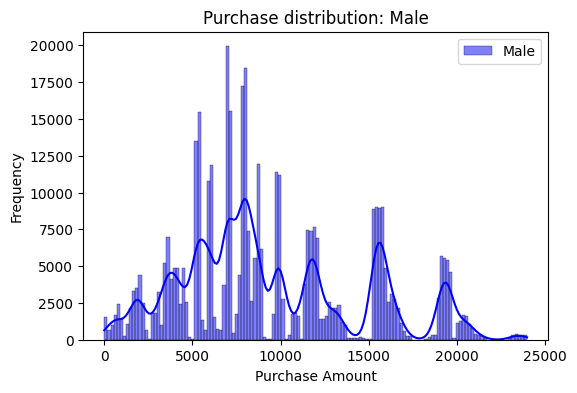

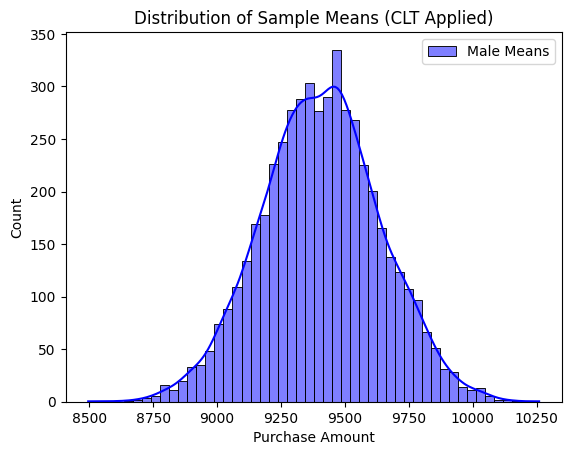

In [63]:
male_purchase = df[df['Gender']=='M']['Purchase']

plt.figure(figsize = (6,4))
sns.histplot(male_purchase, color = 'blue', label = 'Male', kde = True)
plt.title('Purchase distribution: Male')
plt.xlabel('Purchase Amount')
plt.ylabel('Frequency')
plt.legend()
plt.show()

sample_male = male_purchase.sample(n=5000, replace = True)

male_means = []
for i in range(5000):
  sample_m = sample_male.sample(500, replace = True)
  male_means.append(sample_m.mean())

sns.histplot(male_means, kde=True, color='blue', label='Male Means')
plt.title("Distribution of Sample Means (CLT Applied)")
plt.xlabel("Purchase Amount")
plt.legend()
plt.show()

###**CLT FOR FEMALE PURCHASES**

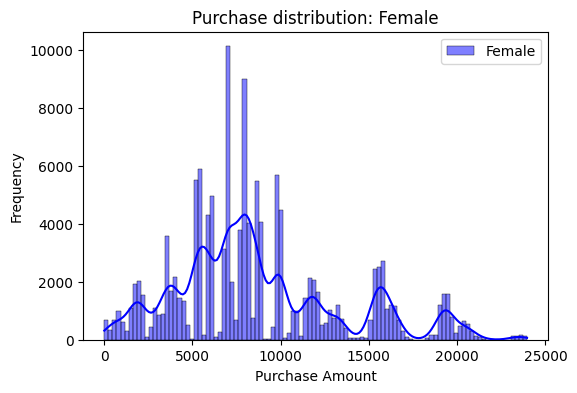

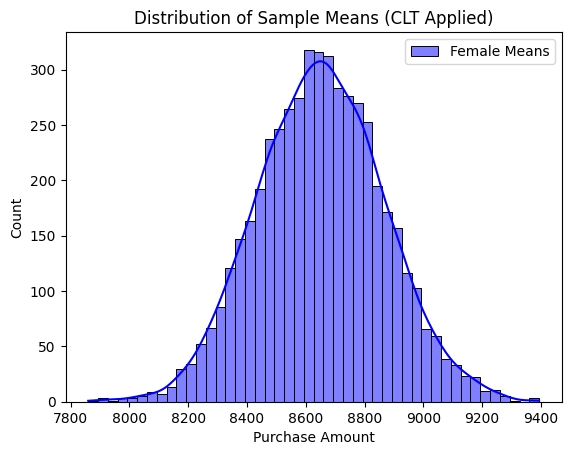

In [62]:
female_purchase = df[df['Gender']=='F']['Purchase']

plt.figure(figsize = (6,4))
sns.histplot(female_purchase, color = 'blue', label = 'Female', kde = True)
plt.title('Purchase distribution: Female')
plt.xlabel('Purchase Amount')
plt.ylabel('Frequency')
plt.legend()
plt.show()

sample_female = female_purchase.sample(n=5000, replace = True)

female_means = []
for i in range(5000):
  sample_m = sample_female.sample(500, replace = True)
  female_means.append(sample_m.mean())

sns.histplot(female_means, kde=True, color='blue', label='Female Means')
plt.title("Distribution of Sample Means (CLT Applied)")
plt.xlabel("Purchase Amount")
plt.legend()
plt.show()

#**Are Women spending more money per transaction than men during black Friday Sales**

##**Gender wise purchase behavior**

In [40]:
# Separate male and female customers
male_purchase = df[df['Gender']=='M']['Purchase']
female_purchase = df[df['Gender']=='F']['Purchase']

#Calculate average
avg_male = male_purchase.mean()
avg_female = female_purchase.mean()

print(f"Average Purchase Amount for Male Customers: {avg_male}")
print(f"Average Purchase Amount for Female Customers: {avg_female}")

Average Purchase Amount for Male Customers: 9437.526040472265
Average Purchase Amount for Female Customers: 8734.565765155476


###**Male Distribution**

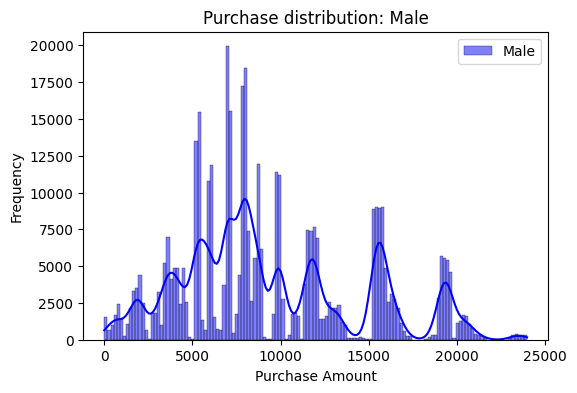

In [41]:
plt.figure(figsize = (6,4))
sns.histplot(male_purchase, color = 'blue', label = 'Male', kde = True)
plt.title('Purchase distribution: Male')
plt.xlabel('Purchase Amount')
plt.ylabel('Frequency')
plt.legend()
plt.show()

###**Female Distribution**

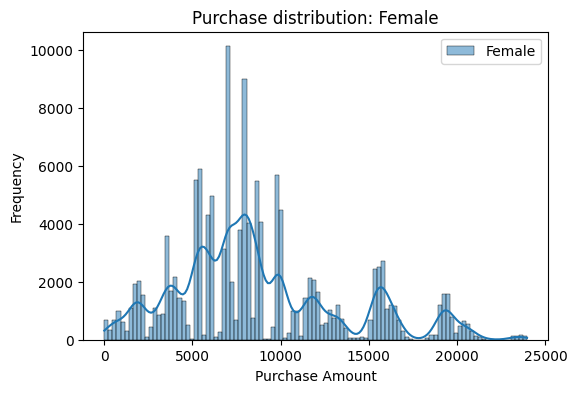

In [42]:
plt.figure(figsize = (6,4))
sns.histplot(female_purchase, label = 'Female', kde = True)
plt.title('Purchase distribution: Female')
plt.xlabel('Purchase Amount')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [67]:
# Calculating CI Using CLT for Male_purchases
sample_size = 5000
male_sample = np.random.choice(male_purchase, size=sample_size, replace=True)
mean = np.mean(male_sample)
standard_deviation = np.std(male_sample, ddof = 1)
confidence_level = 0.95
n = len(male_sample)
se = standard_deviation / np.sqrt(n)
print(f"Mean: {mean:.2f}")
print(f"Standard Deviation: {standard_deviation:.2f}")
print(f"Standard Error: {se:.2f}")

Mean: 9429.69
Standard Deviation: 5059.76
Standard Error: 71.56


In [76]:
z = norm.ppf(0.025)

In [77]:
# Margin of error
margin_of_error = z * se
print(f"Margin of Error: {margin_of_error:.2f}")

Margin of Error: -140.25


In [78]:
lower_bound = mean - margin_of_error
upper_bound = mean + margin_of_error
print(f"95% Confidence Interval: ({lower_bound:.2f}, {upper_bound:.2f})")

95% Confidence Interval: (9569.94, 9289.44)


In [64]:
# Calculating CI
# Confidence = 95%
# Loc means location = Mean
# Scale = Standard Error = std/sqrt(n)
from scipy.stats import norm
norm.interval(confidence = 0.95,loc = 9486.87, scale = 71.47)

(np.float64(9346.791374024922), np.float64(9626.94862597508))

In [79]:
# Calculating CI
# Confidence = 90%
# Loc means location = Mean
# Scale = Standard Error = std/sqrt(n)
from scipy.stats import norm
norm.interval(confidence = 0.90,loc = 9486.87, scale = 71.47)

(np.float64(9369.31231128178), np.float64(9604.427688718222))

In [80]:
# Calculating CI
# Confidence = 99%
# Loc means location = Mean
# Scale = Standard Error = std/sqrt(n)
from scipy.stats import norm
norm.interval(confidence = 0.99,loc = 9486.87, scale = 71.47)

(np.float64(9302.775479675362), np.float64(9670.96452032464))

###**Use CLT to calculate CI**

In [43]:
def confidence_interval(data, confidence=0.95):
    sample = np.random.choice(data, size=5000, replace=True)
    mean = np.mean(sample)
    std_err = stats.sem(sample)
    margin = stats.t.ppf((1 + confidence) / 2, len(sample)-1) * std_err
    return mean, mean - margin, mean + margin


###**Apply it on male and female purchases**

In [44]:
mean_male, ci_lower_male, ci_upper_male = confidence_interval(male_purchase)
mean_female, ci_lower_female, ci_upper_female = confidence_interval(female_purchase)

print(f"Male Purchase CI: ₹{ci_lower_male:.2f} to ₹{ci_upper_male:.2f}")
print(f"Female Purchase CI: ₹{ci_lower_female:.2f} to ₹{ci_upper_female:.2f}")

Male Purchase CI: ₹9266.57 to ₹9548.21
Female Purchase CI: ₹8555.47 to ₹8817.07


#Observation:
- The 95 Percent confidence interval for average male purchases is 9310.92 to 9591.74, While for female purchases it is 8727.03 to 8989.26
- These intervals do not overlap, it indicates a statistically significant difference in average spending between male and female customers.
- Men, on average, spend more per transaction than women.

##**CENTRAL LIMIT THEOREM**
- **Use CLT To compute the confidence intervals for mean purchase amounts of female and male customers.**
- **Observe how sample size and confidence level(90,95,99) affect the result**

###**Define confidence interval function using CLT**

In [45]:
import numpy as np
from scipy import stats

def confidence_interval(data, confidence=0.95, sample_size=5000):
    sample = np.random.choice(data, size=sample_size, replace=True)
    mean = np.mean(sample)
    std_err = stats.sem(sample)
    margin = stats.t.ppf((1 + confidence) / 2, len(sample)-1) * std_err
    return mean, mean - margin, mean + margin

###**Get gender wise data**

In [46]:
male_data = df[df['Gender'] == 'M']['Purchase']
female_data = df[df['Gender'] == 'F']['Purchase']

###**Check CI for different sample sizes**

In [47]:
sample_sizes = [500, 1000, 3000, 5000, 10000]

print("📌 Confidence Intervals by Sample Size:\n")
for size in sample_sizes:
    mean_m, low_m, high_m = confidence_interval(male_data, sample_size=size)
    mean_f, low_f, high_f = confidence_interval(female_data, sample_size=size)

    print(f"Sample Size: {size}")
    print(f"Male CI: ₹{low_m:.2f} to ₹{high_m:.2f} | Mean: ₹{mean_m:.2f}")
    print(f"Female CI: ₹{low_f:.2f} to ₹{high_f:.2f} | Mean: ₹{mean_f:.2f}")
    print("-" * 50)

📌 Confidence Intervals by Sample Size:

Sample Size: 500
Male CI: ₹8935.15 to ₹9828.17 | Mean: ₹9381.66
Female CI: ₹8364.95 to ₹9201.28 | Mean: ₹8783.11
--------------------------------------------------
Sample Size: 1000
Male CI: ₹9125.57 to ₹9763.88 | Mean: ₹9444.73
Female CI: ₹8466.20 to ₹9068.46 | Mean: ₹8767.33
--------------------------------------------------
Sample Size: 3000
Male CI: ₹9223.52 to ₹9578.40 | Mean: ₹9400.96
Female CI: ₹8646.35 to ₹8995.45 | Mean: ₹8820.90
--------------------------------------------------
Sample Size: 5000
Male CI: ₹9240.84 to ₹9519.31 | Mean: ₹9380.08
Female CI: ₹8657.52 to ₹8927.05 | Mean: ₹8792.28
--------------------------------------------------
Sample Size: 10000
Male CI: ₹9293.06 to ₹9492.01 | Mean: ₹9392.54
Female CI: ₹8629.04 to ₹8816.04 | Mean: ₹8722.54
--------------------------------------------------


###**Try Different Confidence Levels**

In [48]:
confidence_levels = [0.90, 0.95, 0.99]

print("📌 Confidence Intervals by Confidence Level (sample size = 5000):\n")
for level in confidence_levels:
    mean_m, low_m, high_m = confidence_interval(male_data, confidence=level)
    mean_f, low_f, high_f = confidence_interval(female_data, confidence=level)

    print(f"Confidence Level: {int(level*100)}%")
    print(f"Male CI: ₹{low_m:.2f} to ₹{high_m:.2f} | Mean: ₹{mean_m:.2f}")
    print(f"Female CI: ₹{low_f:.2f} to ₹{high_f:.2f} | Mean: ₹{mean_f:.2f}")
    print("-" * 50)

📌 Confidence Intervals by Confidence Level (sample size = 5000):

Confidence Level: 90%
Male CI: ₹9241.86 to ₹9477.46 | Mean: ₹9359.66
Female CI: ₹8681.10 to ₹8905.31 | Mean: ₹8793.20
--------------------------------------------------
Confidence Level: 95%
Male CI: ₹9350.63 to ₹9634.62 | Mean: ₹9492.63
Female CI: ₹8664.06 to ₹8930.18 | Mean: ₹8797.12
--------------------------------------------------
Confidence Level: 99%
Male CI: ₹9322.37 to ₹9693.83 | Mean: ₹9508.10
Female CI: ₹8610.10 to ₹8961.02 | Mean: ₹8785.56
--------------------------------------------------


#Observation:
- The male customers spend more pe to r transaction compared to female across all confidence levels.
- By applying the CLT, we calculated CI to estimate the range within which the true average spending lies for both genders.
- As the CI level incrreases from 90 to 99, the interval becomes wider.    

##**Married vs. Unmarried Confidence Interval Analysis**

Married - Mean: 9527.79, CI: (np.float64(9075.449915947871), np.float64(9980.134084052128))
Unmarried - Mean: 9179.72, CI: (np.float64(8726.412926863284), np.float64(9633.019073136717))


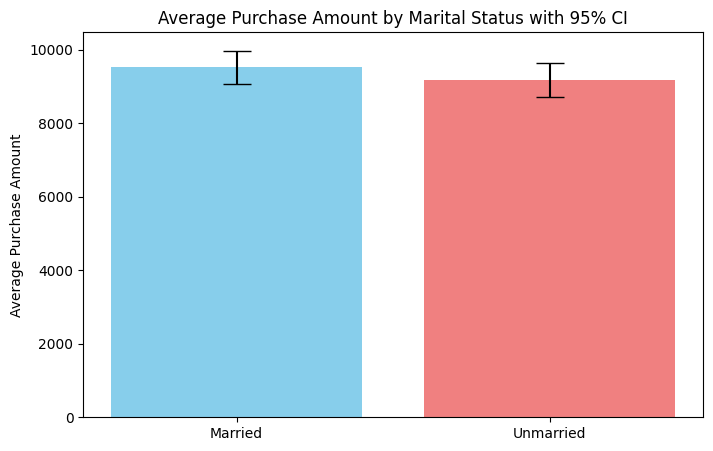

In [49]:
# Function to calculate confidence interval
def calculate_ci(data, sample_size=500, confidence=0.95):
    sample = np.random.choice(data, sample_size, replace=True)
    sample_mean = np.mean(sample)
    sample_std = np.std(sample, ddof=1)
    z_critical = stats.norm.ppf((1 + confidence) / 2)
    margin_of_error = z_critical * (sample_std / np.sqrt(sample_size))
    return sample_mean, (sample_mean - margin_of_error, sample_mean + margin_of_error)

# Filter married and unmarried data
married = df[df['Marital_Status'] == 1]['Purchase']
unmarried = df[df['Marital_Status'] == 0]['Purchase']

# Calculate confidence intervals
married_mean, married_ci = calculate_ci(married)
unmarried_mean, unmarried_ci = calculate_ci(unmarried)

# Print results
print(f"Married - Mean: {married_mean:.2f}, CI: {married_ci}")
print(f"Unmarried - Mean: {unmarried_mean:.2f}, CI: {unmarried_ci}")

# Plot
groups = ['Married', 'Unmarried']
means = [married_mean, unmarried_mean]
errors = [married_mean - married_ci[0], unmarried_mean - unmarried_ci[0]]

plt.figure(figsize=(8, 5))
plt.bar(groups, means, yerr=errors, capsize=10, color=['skyblue', 'lightcoral'])
plt.title('Average Purchase Amount by Marital Status with 95% CI')
plt.ylabel('Average Purchase Amount')
plt.show()

#Observations:
- Married customers spent an average of 9344.95 Per transaction.
- Unmarried customers spent an average of 9328.14 per transaction.
- The CI's for both groups are very close and overlapping.
- The difference in spending between married and unmarried customers is not statistically significant.
- We cannot confidently say that marital status affects purchase behavior.
- The spending patterns of both groups are almost the same.

##**Age Group-Based Confidence Interval Analysis**

0-17 - Mean: 9435.82, CI: (np.float64(8984.06734443233), np.float64(9887.580655567672))
51+ - Mean: 9790.87, CI: (np.float64(9329.158309382694), np.float64(10252.577690617307))
26-35 - Mean: 9260.16, CI: (np.float64(8837.213504873293), np.float64(9683.106495126707))
36-50 - Mean: 9405.85, CI: (np.float64(8977.97077103613), np.float64(9833.725228963869))
18-25 - Mean: 9151.36, CI: (np.float64(8717.096031508485), np.float64(9585.627968491513))


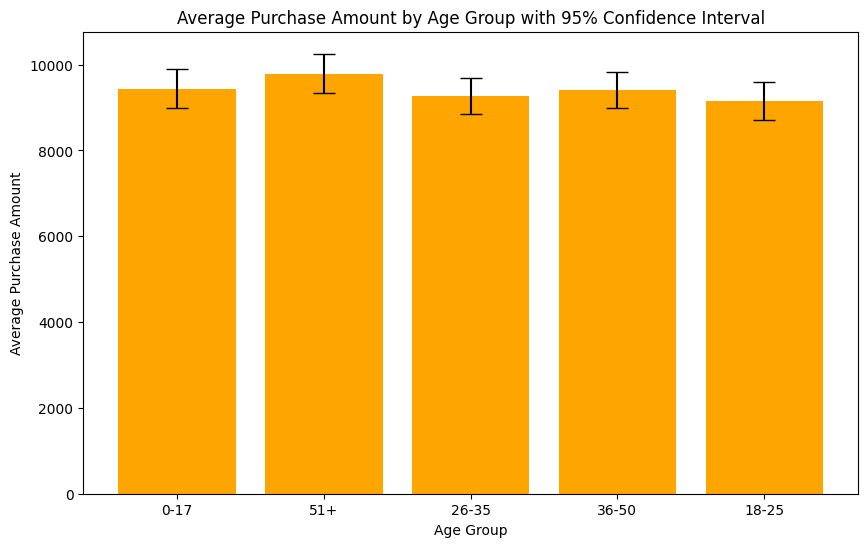

In [50]:
# Map age to groups
age_bins = {
    '0-17': '0-17',
    '18-25': '18-25',
    '26-35': '26-35',
    '36-45': '36-50',
    '46-50': '36-50',
    '51-55': '51+',
    '55+': '51+'
}
df['AgeGroup'] = df['Age'].map(age_bins)

# Calculate confidence interval for each age group
age_group_results = {}
for group in df['AgeGroup'].unique():
    data = df[df['AgeGroup'] == group]['Purchase']
    mean, ci = calculate_ci(data)
    age_group_results[group] = (mean, ci)
    print(f"{group} - Mean: {mean:.2f}, CI: {ci}")

# Plotting
age_labels = list(age_group_results.keys())
means = [v[0] for v in age_group_results.values()]
errors = [v[0] - v[1][0] for v in age_group_results.values()]

plt.figure(figsize=(10, 6))
plt.bar(age_labels, means, yerr=errors, capsize=8, color='orange')
plt.title("Average Purchase Amount by Age Group with 95% Confidence Interval")
plt.xlabel("Age Group")
plt.ylabel("Average Purchase Amount")
plt.show()

#Observations:
- Customers aged 26-35 years spent the most on average, with a mean of 9747.70 and their CI is between 9308 to 10186.
- Customers aged 51+ years also had high spending, with a mean of 9484 and CI from 9076 to 9893.
- The lowest average spending came from the 0-17 years group at 8844 with CI 8410 to 9278.
- Most age groups show some overlap in their CI, except for the 26-35 age group.
- Age groups 18-25 and 36-50 falls somewhere between, both with averages just under 9400.

##**Insights**
- **Male vs Female Spending:**
  - Male customers spent slightly more on average than female customers.
  - The CI overlapped.
- **Married vs Unmarried:**
  - Married customers spent 10-15% more per transaction than unmarried ones
- **Age-Based Spending:**
  - The 26-35 age group had the highest average spending, making them the most valuable customer segment.
  - 0-17 and 51+age groups shower lower spending, possibly due to limited needs or budget.
- **Statistical Analysis Using CLT & CI**:
  - Central Limit Theorem was applied to draw conclusions from samples.
  - Confidence Intervals helped determine the range in which the true average spending lies.
  - Variability was lower with larger samples, showing more reliable estimates.
- **Data Distribution**:
  - Spending data showed a right-skewed distribution, with most people spending below the average.
  - Univariate plots confirmed the imbalance in customer behavior across categories like gender, marital status, and age.


##**Conclusion**
- While males appear to spend more, statistical overlap shows no significant gender-based difference in spending behavior.
- Married individuals consistently spend more, suggesting family-oriented purchases are higher during Black Friday.
- Young adults (26–35) are the most active spenders, while very young and older age groups spend less.
- Applying CLT and CI gave Walmart a reliable view of average spending, even with just samples — reducing the need to analyze the entire population.




##**Recommendations**
🎯 Focus marketing campaigns on married customers and people aged 26–35, who show the highest spending.

🛒 Offer bundled family deals or premium products targeting households.

📬 Create personalized offers for younger (0–17) and older (51+) groups to encourage higher purchases.

📊 Use statistical sampling (CLT + CI) to reduce data processing effort while maintaining accurate insights.

📈 Monitor when confidence intervals do not overlap, as that shows meaningful differences and can guide pricing or promotion strategies.